# Práctica 08 — Feature Engineering con pandas


## 1. Setup y carga de datos

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
print('Entorno configurado correctamente')

Entorno configurado correctamente


In [3]:
# Dataset sintético de viviendas indicado en la consigna
np.random.seed(42)
n_samples = 1000
data = {
    'price': np.random.normal(200000, 50000, n_samples),
    'sqft': np.random.normal(120, 30, n_samples),
    'bedrooms': np.random.choice([1, 2, 3, 4, 5], n_samples),
    'bathrooms': np.random.choice([1, 2, 3], n_samples),
    'year_built': np.random.choice(range(1980, 2024), n_samples),
    'garage_spaces': np.random.choice([0, 1, 2, 3], n_samples),
    'lot_size': np.random.normal(8000, 2000, n_samples),
    'distance_to_city': np.random.normal(15, 8, n_samples),
    'school_rating': np.random.uniform(1, 10, n_samples),
    'crime_rate': np.random.uniform(0, 100, n_samples),
}
df = pd.DataFrame(data)

for column in ['price', 'sqft', 'lot_size', 'distance_to_city']:
    df[column] = df[column].abs()

print(f'Forma: {df.shape}')
display(df.head())
display(df.describe().round(2))

Forma: (1000, 10)


,price,sqft,bedrooms,bathrooms,year_built,garage_spaces,lot_size,distance_to_city,school_rating,crime_rate
0,224835.707651,161.980663,3,1,2001,3,7436.395239,5.131093,4.402225,12.718119
1,193086.784941,147.739010,3,3,2011,3,8196.996696,0.188184,1.926515,39.855922
2,232384.426905,121.788911,3,1,1995,3,8308.096155,20.992112,7.471205,17.015264
3,276151.492820,100.591897,4,3,1997,0,7915.263179,27.394727,5.534999,25.472050
4,188292.331264,140.946699,5,1,1984,1,8133.185144,9.121570,7.378891,26.324617


,price,sqft,bedrooms,bathrooms,year_built,garage_spaces,lot_size,distance_to_city,school_rating,crime_rate
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,200966.60,122.13,2.96,2.04,2001.67,1.48,7964.90,14.91,5.32,49.31
std,48960.80,29.92,1.43,0.82,12.48,1.11,1962.07,7.82,2.56,28.01
min,37936.63,31.79,1.00,1.00,1980.00,0.00,1449.98,0.02,1.00,0.01
25%,167620.48,101.81,2.00,1.00,1991.75,1.00,6677.96,9.14,3.09,26.41
50%,201265.03,121.89,3.00,2.00,2002.00,1.00,7937.43,14.69,5.11,49.37
75%,232397.19,141.87,4.00,3.00,2012.00,2.00,9246.22,20.14,7.47,72.74
max,392636.57,215.79,5.00,3.00,2023.00,3.00,14029.42,40.92,9.96,99.86


## 2. Creación de features derivadas

Se crean ratios, variables temporales, transformaciones matemáticas y scores compuestos. Para que los scores no queden dominados por variables con escalas grandes, primero se normalizan sus componentes al rango 0–1.

In [4]:
df_enhanced = df.copy()
current_year = 2024

# 1) Ratios y proporciones
df_enhanced['price_per_sqft'] = df_enhanced['price'] / df_enhanced['sqft']
df_enhanced['sqft_per_bedroom'] = df_enhanced['sqft'] / df_enhanced['bedrooms']
df_enhanced['bedroom_bathroom_ratio'] = df_enhanced['bedrooms'] / df_enhanced['bathrooms']
df_enhanced['building_density'] = df_enhanced['sqft'] / df_enhanced['lot_size']

# 2) Variables temporales
df_enhanced['property_age'] = current_year - df_enhanced['year_built']
df_enhanced['age_category'] = pd.cut(
    df_enhanced['property_age'],
    bins=[-1, 5, 20, 40, np.inf],
    labels=['nueva', 'moderna', 'madura', 'antigua'],
)
df_enhanced['is_new_property'] = (df_enhanced['property_age'] <= 5).astype(int)
df_enhanced['decade_built'] = (df_enhanced['year_built'] // 10) * 10

# 3) Transformaciones matemáticas
df_enhanced['log_price'] = np.log(df_enhanced['price'])
df_enhanced['sqrt_sqft'] = np.sqrt(df_enhanced['sqft'])
df_enhanced['sqft_squared'] = df_enhanced['sqft'] ** 2

# 4) Features compuestas. Esta función lleva cada componente al rango 0-1.
def minmax(series):
    span = series.max() - series.min()
    return (series - series.min()) / span if span != 0 else pd.Series(0.0, index=series.index)

df_enhanced['luxury_score'] = (
    0.45 * minmax(df_enhanced['sqft'])
    + 0.30 * minmax(df_enhanced['garage_spaces'])
    + 0.25 * minmax(df_enhanced['bathrooms'])
)
df_enhanced['location_score'] = (
    0.40 * (1 - minmax(df_enhanced['distance_to_city']))
    + 0.35 * minmax(df_enhanced['school_rating'])
    + 0.25 * (1 - minmax(df_enhanced['crime_rate']))
)

created = [column for column in df_enhanced.columns if column not in df.columns]
print(f'Dataset original: {df.shape[1]} columnas')
print(f'Dataset con features: {df_enhanced.shape[1]} columnas')
print(f'Features creadas ({len(created)}): {created}')
display(df_enhanced.head())

Dataset original: 10 columnas
Dataset con features: 23 columnas
Features creadas (13): ['price_per_sqft', 'sqft_per_bedroom', 'bedroom_bathroom_ratio', 'building_density', 'property_age', 'age_category', 'is_new_property', 'decade_built', 'log_price', 'sqrt_sqft', 'sqft_squared', 'luxury_score', 'location_score']


,price,sqft,bedrooms,bathrooms,year_built,garage_spaces,lot_size,distance_to_city,school_rating,crime_rate,...,building_density,property_age,age_category,is_new_property,decade_built,log_price,sqrt_sqft,sqft_squared,luxury_score,location_score
0,224835.707651,161.980663,3,1,2001,3,7436.395239,5.131093,4.402225,12.718119,...,0.021782,23,madura,0,2000,12.323125,12.727162,26237.735218,0.618397,0.701009
1,193086.784941,147.739010,3,3,2011,3,8196.996696,0.188184,1.926515,39.855922,...,0.018024,13,moderna,0,2010,12.170895,12.154794,21826.815220,0.833567,0.584725
2,232384.426905,121.788911,3,1,1995,3,8308.096155,20.992112,7.471205,17.015264,...,0.014659,29,madura,0,1990,12.356148,11.035801,14832.538866,0.520104,0.654975
3,276151.492820,100.591897,4,3,1997,0,7915.263179,27.394727,5.534999,25.472050,...,0.012709,27,madura,0,1990,12.528705,10.029551,10118.729675,0.418265,0.495564
4,188292.331264,140.946699,5,1,1984,1,8133.185144,9.121570,7.378891,26.324617,...,0.017330,40,madura,0,1980,12.145751,11.872098,19865.972074,0.366956,0.744165


## 3. Distribución y detección de outliers

,price_per_sqft,sqft_per_bedroom,bedroom_bathroom_ratio,building_density,property_age,log_price,sqrt_sqft,sqft_squared
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,1776.39,57.15,1.77,0.02,22.33,12.18,10.96,15809.07
std,726.68,39.58,1.25,0.01,12.48,0.26,1.40,7376.84
min,278.61,6.36,0.33,0.00,1.00,10.54,5.64,1010.50
25%,1287.19,28.99,1.00,0.01,12.00,12.03,10.09,10365.84
50%,1646.13,41.55,1.50,0.02,22.00,12.21,11.04,14857.74
75%,2112.68,74.27,2.50,0.02,32.25,12.36,11.91,20126.10
max,5521.03,199.33,5.00,0.08,44.00,12.88,14.69,46566.72


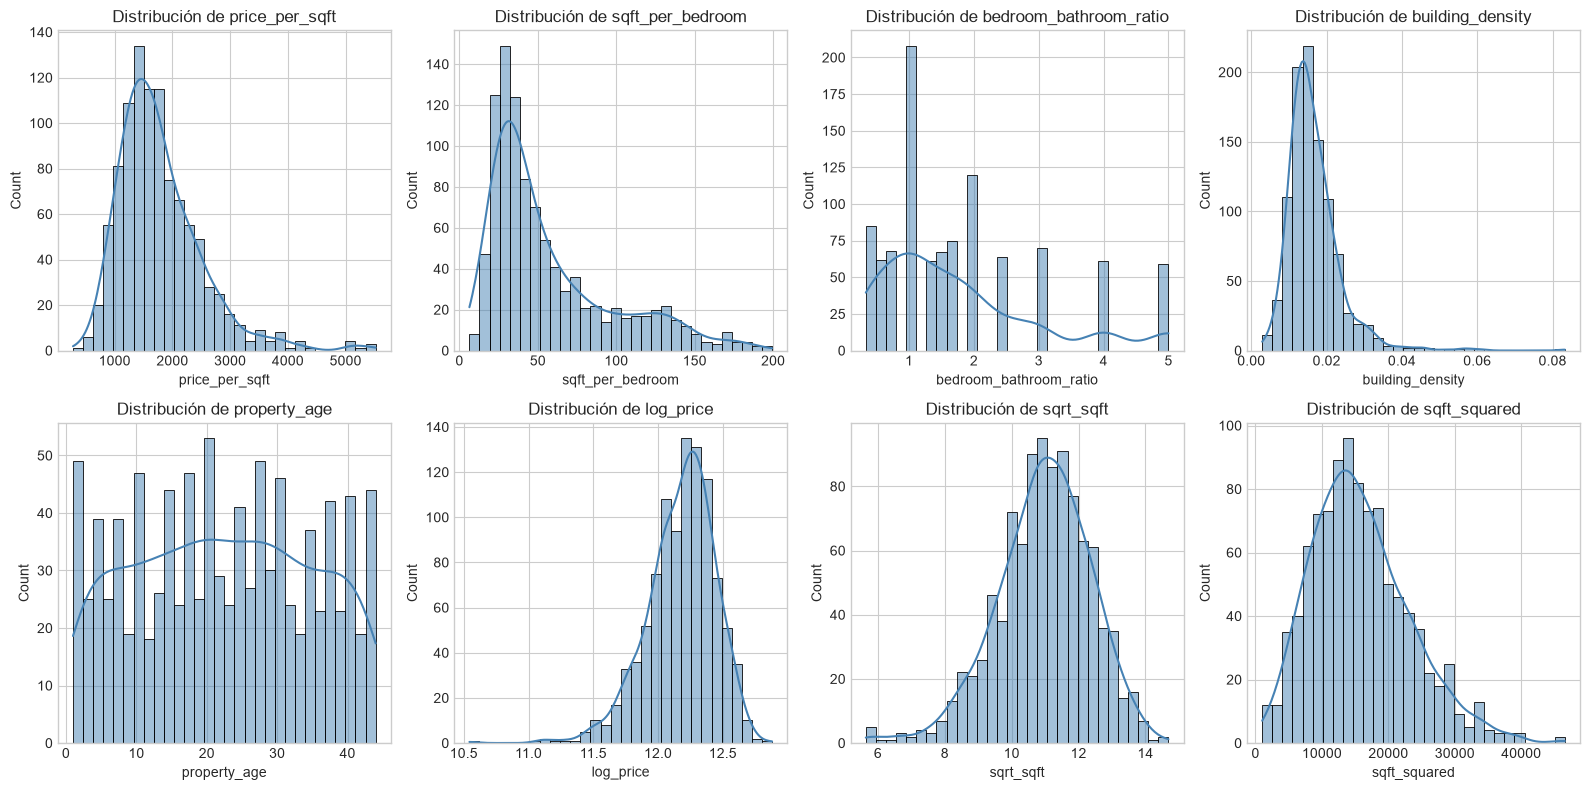

In [5]:
new_features = [
    'price_per_sqft', 'sqft_per_bedroom', 'bedroom_bathroom_ratio',
    'building_density', 'property_age', 'log_price', 'sqrt_sqft',
    'sqft_squared',
]
display(df_enhanced[new_features].describe().round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, feature in zip(axes.ravel(), new_features):
    sns.histplot(df_enhanced[feature], bins=30, kde=True, ax=axis, color='steelblue')
    axis.set_title(f'Distribución de {feature}')
plt.tight_layout()
plt.show()

In [6]:
def detect_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
    return dataframe.loc[mask], lower_bound, upper_bound

outlier_rows = []
for feature in ['price_per_sqft', 'sqft_per_bedroom', 'property_age']:
    outliers, lower, upper = detect_outliers_iqr(df_enhanced, feature)
    outlier_rows.append({
        'feature': feature,
        'outliers': len(outliers),
        'porcentaje': 100 * len(outliers) / len(df_enhanced),
        'límite_inferior': lower,
        'límite_superior': upper,
    })
outlier_summary = pd.DataFrame(outlier_rows).set_index('feature')
display(outlier_summary.round(2))

,outliers,porcentaje,límite_inferior,límite_superior
feature,,,,
price_per_sqft,37,3.7,48.94,3350.93
sqft_per_bedroom,45,4.5,-38.94,142.20
property_age,0,0.0,-18.38,62.62


## 4. Importancia de features

Primero se reproduce el análisis solicitado. Debe interpretarse como **asociación exploratoria**, porque incluye variables construidas a partir del target.

Top 10 — Mutual Information


,feature,mutual_info
14,log_price,5.4759
9,price_per_sqft,0.4459
12,building_density,0.0303
1,bedrooms,0.0189
15,sqrt_sqft,0.0092
0,sqft,0.0078
16,sqft_squared,0.0065
10,sqft_per_bedroom,0.0060
7,school_rating,0.0000
6,distance_to_city,0.0000


Top 10 — Random Forest


,feature,importance
14,log_price,0.9986
9,price_per_sqft,0.0004
7,school_rating,0.0002
0,sqft,0.0002
15,sqrt_sqft,0.0001
10,sqft_per_bedroom,0.0001
12,building_density,0.0001
16,sqft_squared,0.0001
6,distance_to_city,0.0001
5,lot_size,0.0001


Top 10 — correlación absoluta con price


,correlación
log_price,0.9789
price_per_sqft,0.5968
crime_rate,0.0706
sqft,-0.0404
sqft_squared,-0.0399
sqrt_sqft,-0.0377
garage_spaces,-0.0328
school_rating,0.0326
building_density,-0.0312
property_age,0.0311


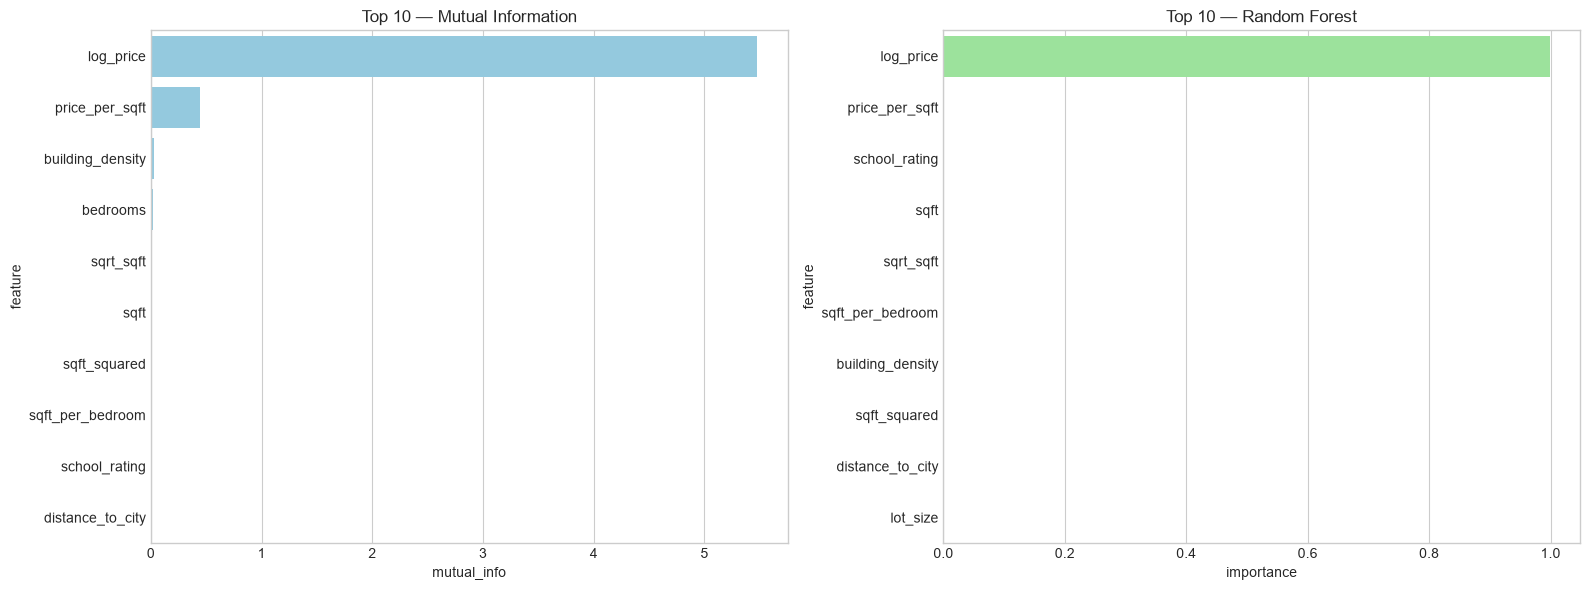

In [7]:
numeric_features = [
    'sqft', 'bedrooms', 'bathrooms', 'year_built', 'garage_spaces',
    'lot_size', 'distance_to_city', 'school_rating', 'crime_rate',
    'price_per_sqft', 'sqft_per_bedroom', 'bedroom_bathroom_ratio',
    'building_density', 'property_age', 'log_price', 'sqrt_sqft',
    'sqft_squared',
]
X = df_enhanced[numeric_features].fillna(0)
y = df_enhanced['price']

mi_df = pd.DataFrame({
    'feature': numeric_features,
    'mutual_info': mutual_info_regression(X, y, random_state=42),
}).sort_values('mutual_info', ascending=False)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

correlations = (
    df_enhanced[numeric_features + ['price']].corr(numeric_only=True)['price']
    .drop('price').sort_values(key=abs, ascending=False)
)
print('Top 10 — Mutual Information')
display(mi_df.head(10).round(4))
print('Top 10 — Random Forest')
display(rf_importance.head(10).round(4))
print('Top 10 — correlación absoluta con price')
display(correlations.head(10).to_frame('correlación').round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=mi_df.head(10), x='mutual_info', y='feature', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 — Mutual Information')
sns.barplot(data=rf_importance.head(10), x='importance', y='feature', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 — Random Forest')
plt.tight_layout()
plt.show()

## 5. Investigación libre

,correlación_con_price
price_age_interaction,0.3692
space_efficiency,-0.0312
crowded_property,0.0259
new_large_property,-0.0189
distance_school_interaction,0.0094
location_score,0.0007


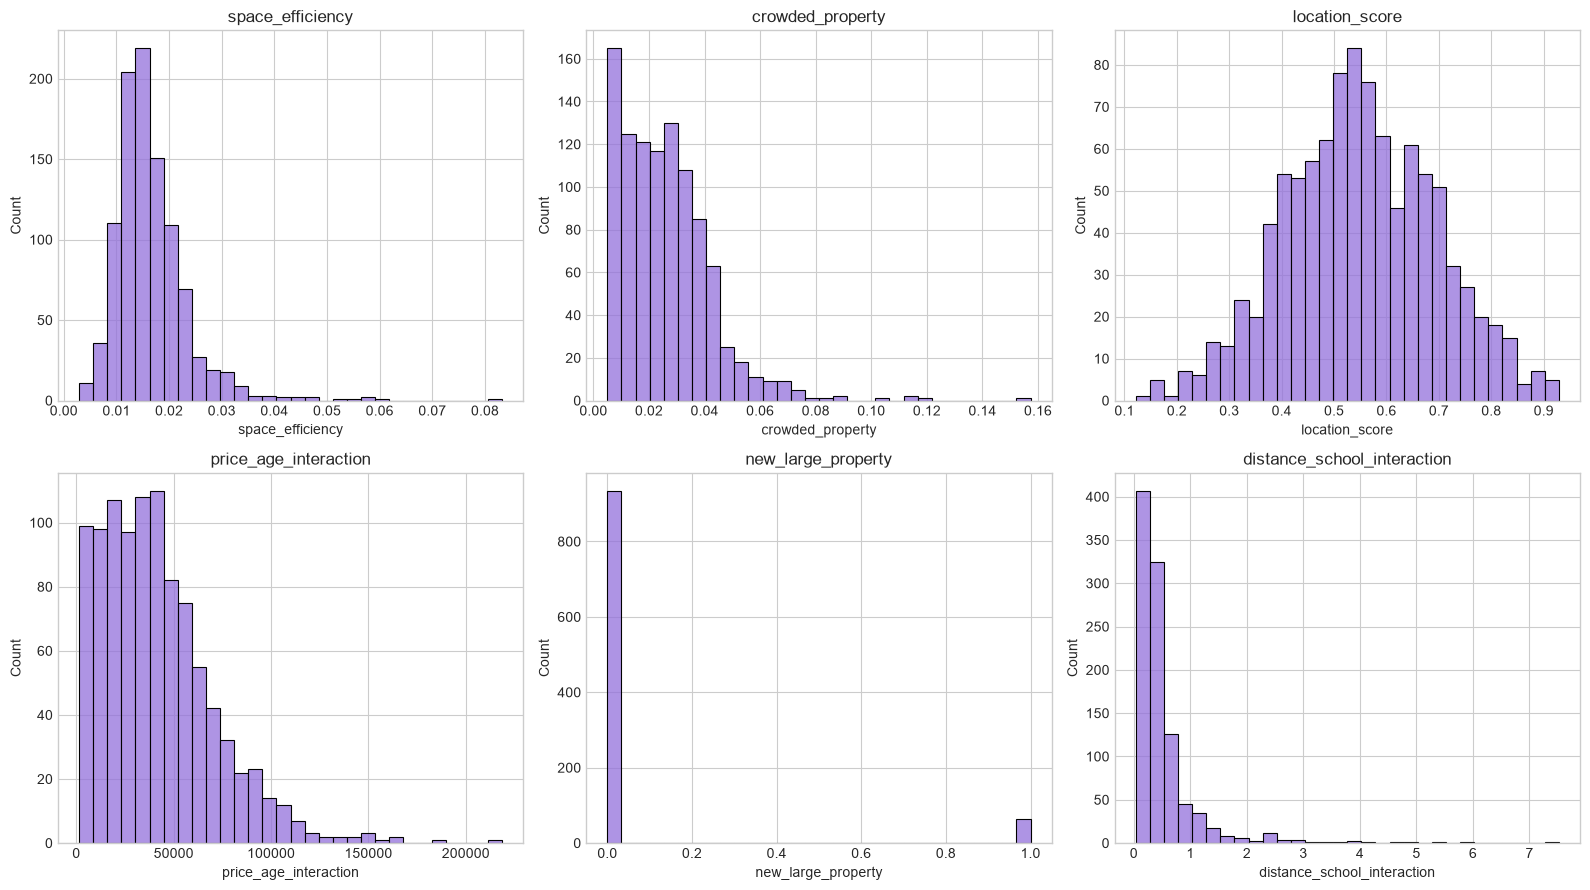

In [8]:
# Desafío 1: conocimiento de dominio
df_enhanced['space_efficiency'] = df_enhanced['sqft'] / df_enhanced['lot_size']
df_enhanced['crowded_property'] = df_enhanced['bedrooms'] / df_enhanced['sqft']
# location_score ya combina cercanía, calidad escolar y baja criminalidad.

# Desafío 2: interacciones
df_enhanced['price_age_interaction'] = df_enhanced['price_per_sqft'] * (1 + df_enhanced['property_age'])
df_enhanced['new_large_property'] = (
    (df_enhanced['is_new_property'] == 1) & (df_enhanced['sqft'] > df_enhanced['sqft'].median())
).astype(int)
df_enhanced['distance_school_interaction'] = (
    df_enhanced['school_rating'] / (1 + df_enhanced['distance_to_city'])
)

research_features = [
    'space_efficiency', 'crowded_property', 'location_score',
    'price_age_interaction', 'new_large_property',
    'distance_school_interaction',
]
research_correlations = (
    df_enhanced[research_features + ['price']].corr(numeric_only=True)['price']
    .drop('price').sort_values(key=abs, ascending=False)
)
display(research_correlations.to_frame('correlación_con_price').round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, feature in zip(axes.ravel(), research_features):
    sns.histplot(df_enhanced[feature], bins=30, ax=axis, color='mediumpurple')
    axis.set_title(feature)
plt.tight_layout()
plt.show()

### Reflexión obligatoria

1. **¿Qué features creé y por qué?** Creé ratios de espacio y comodidad, antigüedad y década, transformaciones para reducir asimetría, scores normalizados de lujo/ubicación e interacciones. Cada una intenta representar un concepto inmobiliario que no aparece directamente en una sola columna.
2. **¿Qué patrones esperaba?** Esperaba que mayor superficie, mejores servicios y mejor ubicación se asociaran con precios altos, mientras que antigüedad, criminalidad y distancia se asociaran negativamente.
3. **¿Coincidieron los resultados?** No necesariamente: el dataset se generó con `price` independiente del resto de las variables. Por eso las correlaciones de features legítimas son débiles; las relaciones fuertes de `log_price`, `price_per_sqft` y `price_age_interaction` son consecuencia de incorporar el propio target.
4. **¿Cuál fue la feature más creativa?** `location_score`, porque resume tres dimensiones con direcciones distintas —cercanía, escuela y seguridad— después de llevarlas a una escala comparable.
5. **¿Qué agregaría con más tiempo?** Calidad y estado de conservación, reformas, coordenadas, accesibilidad al transporte, amenities, estacionalidad de venta y estadísticas del vecindario calculadas sin fuga entre train y test.

## 6. Aplicación a la muestra de Ames Housing

In [9]:
ames_data = {
    'SalePrice': [215000, 105000, 172000, 244000, 189900],
    'GrLivArea': [1710, 856, 1262, 1710, 1362],
    'BedroomAbvGr': [3, 3, 3, 3, 3],
    'FullBath': [2, 1, 2, 2, 1],
    'YearBuilt': [2003, 1961, 1958, 2000, 1992],
    'GarageCars': [2, 1, 2, 2, 1],
    'LotArea': [8450, 9600, 11250, 9550, 10140],
    'Neighborhood': ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel'],
}
ames_df = pd.DataFrame(ames_data)
ames_df['price_per_sqft'] = ames_df['SalePrice'] / ames_df['GrLivArea']
ames_df['property_age'] = current_year - ames_df['YearBuilt']
ames_df['space_efficiency'] = ames_df['GrLivArea'] / ames_df['LotArea']
ames_df['sqft_per_bedroom'] = ames_df['GrLivArea'] / ames_df['BedroomAbvGr']
ames_df['bathroom_bedroom_ratio'] = ames_df['FullBath'] / ames_df['BedroomAbvGr']
ames_df['has_2plus_garage'] = (ames_df['GarageCars'] >= 2).astype(int)
ames_df['decade_built'] = (ames_df['YearBuilt'] // 10) * 10
ames_df['neighborhood_frequency'] = (
    ames_df['Neighborhood'].map(ames_df['Neighborhood'].value_counts(normalize=True))
)
display(ames_df.round(3))
display(
    ames_df.select_dtypes('number').corr()['SalePrice']
    .sort_values(key=abs, ascending=False).to_frame('correlación_con_precio').round(3)
)

,SalePrice,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,LotArea,Neighborhood,price_per_sqft,property_age,space_efficiency,sqft_per_bedroom,bathroom_bedroom_ratio,has_2plus_garage,decade_built,neighborhood_frequency
0,215000,1710,3,2,2003,2,8450,CollgCr,125.731,21,0.202,570.000,0.667,1,2000,0.2
1,105000,856,3,1,1961,1,9600,Veenker,122.664,63,0.089,285.333,0.333,0,1960,0.2
2,172000,1262,3,2,1958,2,11250,Crawfor,136.292,66,0.112,420.667,0.667,1,1950,0.2
3,244000,1710,3,2,2000,2,9550,NoRidge,142.690,24,0.179,570.000,0.667,1,2000,0.2
4,189900,1362,3,1,1992,1,10140,Mitchel,139.427,32,0.134,454.000,0.333,0,1990,0.2


,correlación_con_precio
SalePrice,1.000
GrLivArea,0.975
sqft_per_bedroom,0.975
space_efficiency,0.875
YearBuilt,0.822
property_age,-0.822
decade_built,0.777
FullBath,0.658
GarageCars,0.658
has_2plus_garage,0.658


### Comparación entre datos sintéticos y reales

En Ames aparecen relaciones más plausibles entre precio, superficie, baños, garage y antigüedad. Sin embargo, con solo cinco observaciones cualquier correlación es inestable y no debe generalizarse. `Neighborhood` podría codificarse mediante one-hot encoding o estadísticas calculadas exclusivamente sobre el conjunto de entrenamiento.

## 7. Comprobación predictiva sin fuga de información

Se comparan variables originales con variables derivadas que **no usan `price`**. Como el precio sintético fue generado de manera independiente, no debería aparecer una mejora predictiva real.

In [10]:
original_features = [
    'sqft', 'bedrooms', 'bathrooms', 'year_built', 'garage_spaces',
    'lot_size', 'distance_to_city', 'school_rating', 'crime_rate',
]
safe_engineered_features = original_features + [
    'sqft_per_bedroom', 'bedroom_bathroom_ratio', 'building_density',
    'property_age', 'is_new_property', 'decade_built', 'sqrt_sqft',
    'sqft_squared', 'luxury_score', 'location_score', 'crowded_property',
    'new_large_property', 'distance_school_interaction',
]
train_idx, test_idx = train_test_split(
    np.arange(len(df_enhanced)), test_size=0.25, random_state=42
)

comparison = []
for name, features in {
    'Originales': original_features,
    'Originales + derivadas seguras': safe_engineered_features,
}.items():
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(df_enhanced.loc[train_idx, features], y.iloc[train_idx])
    prediction = model.predict(df_enhanced.loc[test_idx, features])
    comparison.append({
        'conjunto': name,
        'MAE': mean_absolute_error(y.iloc[test_idx], prediction),
        'R²': r2_score(y.iloc[test_idx], prediction),
    })

comparison_df = pd.DataFrame(comparison).set_index('conjunto')
display(comparison_df.round(3))
print('Conclusión: un R² cercano a 0 o negativo es coherente con un target generado al azar.')

,MAE,R²
conjunto,,
Originales,40665.106,-0.088
Originales + derivadas seguras,40805.121,-0.090


Conclusión: un R² cercano a 0 o negativo es coherente con un target generado al azar.


## Conclusión

La práctica muestra que feature engineering no consiste únicamente en producir más columnas: cada transformación debe tener sentido de dominio, una escala adecuada y una evaluación honesta. En estos datos, las variables aparentemente más poderosas son las que reutilizan el target; al excluirlas, el desempeño refleja correctamente que el proceso generador no contiene señal predictiva.